In [381]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

with open("names.txt", "r") as f:
    names = f.read().splitlines()

# print 5 sample names
names[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [382]:
# total number of names in dataset
len(names)

32033

In [383]:
# Create data sets (the input n-gram and corresponding expected label)
n = 3 # The n in n-gram

# Map characters to integer indices ('.' is the boundary/padding token)
chars = ['.'] + sorted(set(''.join(names)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

X = []
Y = []
for name in names:
    window = "." * n
    for ch in name + ".":
        X.append([stoi[c] for c in window])
        Y.append(stoi[ch])
        #print(f"{window} -> {ch}")
        window = window[1:] + ch

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape


(torch.Size([228146, 3]), torch.Size([228146]))

In [384]:
# === 1st layer === 
# Consists of a simple lookup of each element in the embeddings matrix
# Linear layer
EMBEDDING_DIMENSIONS = 3
C = torch.randn(27, EMBEDDING_DIMENSIONS)
one_hot = F.one_hot(X, num_classes=27).float()
embedding = one_hot @ C
one_hot.shape, C.shape, embedding.shape

(torch.Size([228146, 3, 27]), torch.Size([27, 3]), torch.Size([228146, 3, 3]))

In [398]:
# === 2nd layer ===
# tanh layer has 100 neurons. Each neuron has 6 inputs, and it has 100 outputs
# we need a weight matrix that converts 6 inputs -> 100 outputs
# we also need a bias that's of size 100, one for each neuron
torch.manual_seed(100)
W1 = torch.randn(3 * EMBEDDING_DIMENSIONS, 100)
b1 = torch.randn(1, 100)
tanh_activations = torch.tanh(embedding.view(-1, 3*EMBEDDING_DIMENSIONS) @ W1 + b1)
tanh_activations.shape

torch.Size([32, 100])

In [399]:
# === 3rd layer ===
# Softmax
# We need 27 outputs, and we have a 100 inputs, so we need a weight matrix
# that is of shape (100, 27)
W2 = torch.randn(100, 27)
b2 = torch.randn(27)
logits = tanh_activations @ W2 + b2

# Logits compuation - here for explanation reasons, but better to 
# use the cross_entropy function
#counts = logits.exp()
#per_sample_counts = counts.sum(1, keepdim=True)
#softmax = counts/per_sample_counts
#softmax.shape

In [400]:
# Loss computation
# From the softmax array, pick out the probability that the model assigned to 
# the actual next character based on the labels (Y). This gives us one probability
# per sample - so we have 32 total probabilities. Then compute NLL across all the 32
# probabilities to obtain loss.
#probs = softmax[torch.arange(32), Y] 
#nll = -torch.log(probs).mean()
loss = F.cross_entropy(logits, Y)

ValueError: Expected input batch_size (32) to match target batch_size (228146).

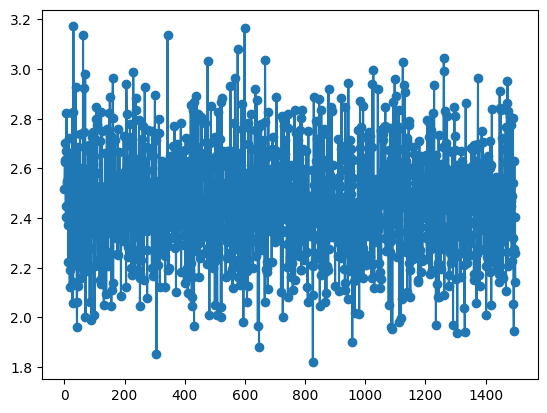

tensor(2.1421, grad_fn=<NllLossBackward0>)

In [407]:
# Training

# Gather all the parameters
# C (27, 2)
# W1 (6, 100)
# W2 (100, 27)
# b1 (1, 100)
# b2 (1, 27)
params = [C, W1, W2, b1, b2]

for p in params:
    p.requires_grad = True

x_axis_points = []
y_axis_points = []

lr_lin = torch.linspace(-3, 0, 500)
lr_exp = 10**lr_lin
lr_points = []
loss_points = []

# Training loop
for i in range(1500):

    # construct a batch instead of training on all examples
    batch_indexes = torch.randint(0, X.size(0), (32,))
    
    # Forward pass
    one_hot = F.one_hot(X[batch_indexes], num_classes=27).float() # (32, 3, 27)
    embedding = one_hot @ C # (32, 3, 2)
    tanh_activations = torch.tanh(embedding.view(-1, 3*EMBEDDING_DIMENSIONS) @ W1 + b1)
    logits = tanh_activations @ W2 + b2
    loss = F.cross_entropy(logits, Y[batch_indexes])
    y_axis_points.append(loss.item())
    x_axis_points.append(i)

    # Backward pass
    for p in params:
        p.grad = None
    loss.backward()
    lr = 0.05 # -lr_exp[i]
    for p in params:
        p.data += -lr * p.grad

    #lr_points.append(lr_exp[i])
    #loss_points.append(loss.item())

plt.plot(x_axis_points, y_axis_points, marker='o', linestyle='-')
plt.show()
#plt.plot(lr_points, loss_points, marker='o', linestyle='-')
#plt.show()
loss


In [409]:
# sample the neural net to get name sounding things ...

g = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    out = []
    context = [0] * 3
    context = torch.tensor(context)
    while True:
        one_hot = F.one_hot(context, num_classes=27).float()
        embedding = one_hot @ C
        tanh_activations = torch.tanh(embedding.view(-1, 3*EMBEDDING_DIMENSIONS) @ W1 + b1)
        logits = tanh_activations @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = torch.cat([context[1:], torch.tensor([ix])])
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

dex.
daleal.
uraila.
kayda.
vonie.
tea.
nel.
avi.
kana.
ara.
zopullansr.
gotai.
mozie.
cavo.
kerteda.
kaleria.
sadeu.
akaviyny.
fobs.
mhinine.


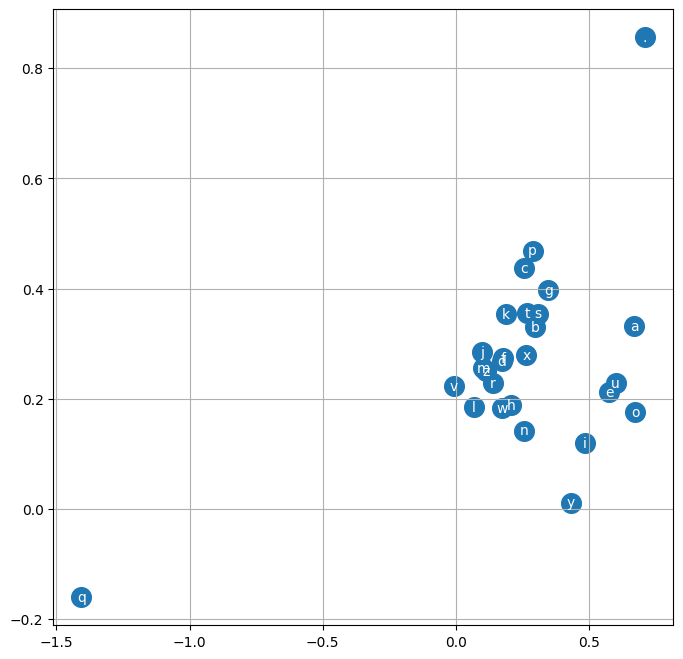

In [369]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')